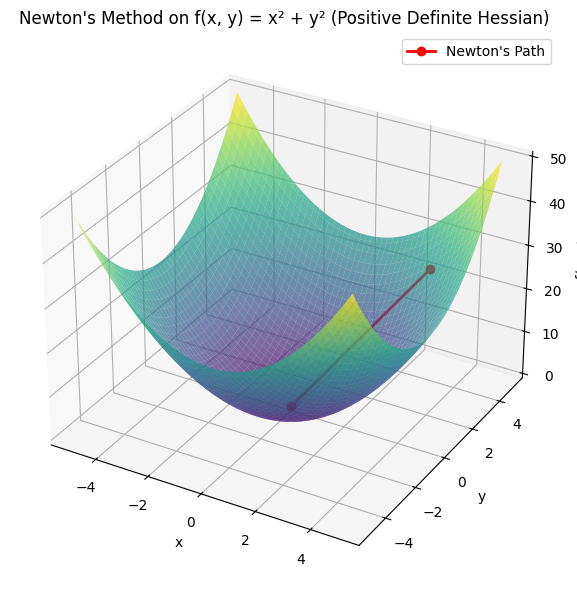

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the quadratic function f(x, y) = x^2 + y^2
def f(x, y):
    return x**2 + y**2

# Gradient: ∇f = [2x, 2y]
def grad(x):
    return np.array([2*x[0], 2*x[1]])

# Hessian: H = [[2, 0], [0, 2]] (positive definite)
H = np.array([[2, 0], [0, 2]])
H_inv = np.linalg.inv(H)

# Start at a point (3, 4)
x_vals = [np.array([3.0, 4.0])]

# Newton's step: x_new = x - H⁻¹ * grad(x)
for i in range(2):  # Should converge in 1 step for this function
    x_new = x_vals[-1] - H_inv @ grad(x_vals[-1])
    x_vals.append(x_new)

# Extract x and y for plotting path
path = np.array(x_vals)
x_path, y_path = path[:, 0], path[:, 1]

# Create a meshgrid for surface plot
X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
Z = f(X, Y)

# Plot the surface and Newton's path
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax.plot(x_path, y_path, f(x_path, y_path), color='red', marker='o', linewidth=2, label="Newton's Path")
ax.set_title("Newton's Method on f(x, y) = x² + y² (Positive Definite Hessian)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.legend()
plt.tight_layout()
plt.show()


Here's the visual you requested!

In the plot above:

The surface is the bowl-shaped loss function: 
f(x,y)=x2+y2
 
The red dots and line show how Newton’s method jumps:
- It starts at (3, 4)
- Takes just one smart step
- Lands exactly at the minimum (0, 0)

This happens because the Hessian is positive definite, which gives Newton’s method precise knowledge of the curvature — allowing it to go directly to the bottom.

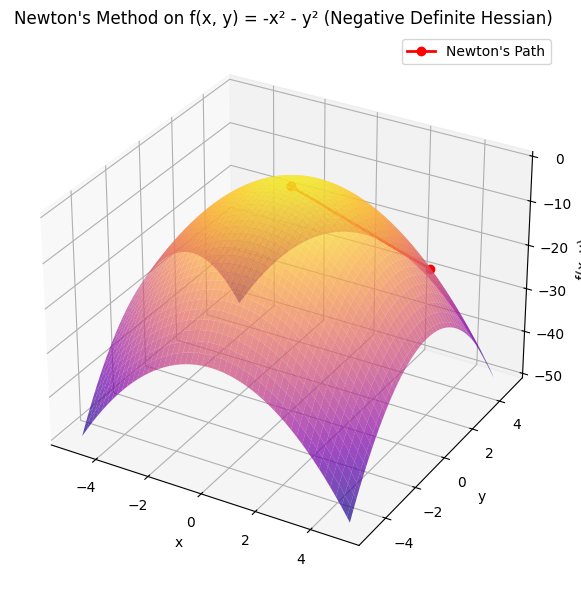

In [4]:
# Define the upside-down quadratic function f(x, y) = -x^2 - y^2 (negative definite)
def f_neg(x, y):
    return -x**2 - y**2

# Gradient: ∇f = [-2x, -2y]
def grad_neg(x):
    return np.array([-2*x[0], -2*x[1]])

# Hessian: H = [[-2, 0], [0, -2]] (negative definite)
H_neg = np.array([[-2, 0], [0, -2]])
H_neg_inv = np.linalg.inv(H_neg)

# Start at the same point (3, 4)
x_vals_neg = [np.array([3.0, 4.0])]

# Apply Newton's method
for i in range(2):  # Try 2 steps
    x_new = x_vals_neg[-1] - H_neg_inv @ grad_neg(x_vals_neg[-1])
    x_vals_neg.append(x_new)

# Extract x and y for plotting path
path_neg = np.array(x_vals_neg)
x_path_neg, y_path_neg = path_neg[:, 0], path_neg[:, 1]

# Create a meshgrid for surface plot
Z_neg = f_neg(X, Y)

# Plot the surface and Newton's path
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z_neg, cmap='plasma', alpha=0.7)
ax.plot(x_path_neg, y_path_neg, f_neg(x_path_neg, y_path_neg), color='red', marker='o', linewidth=2, label="Newton's Path")
ax.set_title("Newton's Method on f(x, y) = -x² - y² (Negative Definite Hessian)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.legend()
plt.tight_layout()
plt.show()


What’s happening here?
- The surface is an upside-down bowl (hill)
- The red dots show Newton’s method trying to minimize
- But it jumps away from the peak, moving in the wrong direction
- Each step increases the function value instead of decreasing it


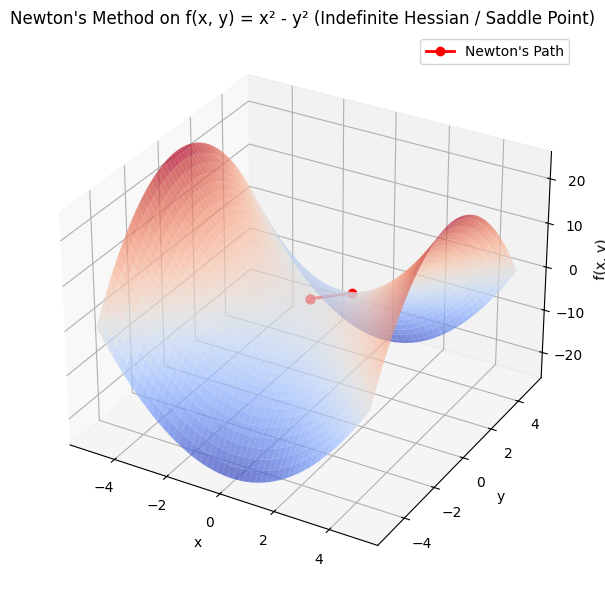

In [5]:
# Define a saddle-shaped function: f(x, y) = x^2 - y^2 (indefinite Hessian)
def f_saddle(x, y):
    return x**2 - y**2

# Gradient: ∇f = [2x, -2y]
def grad_saddle(x):
    return np.array([2*x[0], -2*x[1]])

# Hessian: H = [[2, 0], [0, -2]] (indefinite)
H_saddle = np.array([[2, 0], [0, -2]])
H_saddle_inv = np.linalg.inv(H_saddle)

# Start at a point near the saddle (1, 1)
x_vals_saddle = [np.array([1.0, 1.0])]

# Apply Newton's method
for i in range(3):  # Try 3 steps to show instability
    x_new = x_vals_saddle[-1] - H_saddle_inv @ grad_saddle(x_vals_saddle[-1])
    x_vals_saddle.append(x_new)

# Extract x and y for plotting path
path_saddle = np.array(x_vals_saddle)
x_path_saddle, y_path_saddle = path_saddle[:, 0], path_saddle[:, 1]

# Create a meshgrid for the saddle surface
Z_saddle = f_saddle(X, Y)

# Plot the surface and Newton's path
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z_saddle, cmap='coolwarm', alpha=0.7)
ax.plot(x_path_saddle, y_path_saddle, f_saddle(x_path_saddle, y_path_saddle), color='red', marker='o', linewidth=2, label="Newton's Path")
ax.set_title("Newton's Method on f(x, y) = x² - y² (Indefinite Hessian / Saddle Point)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.legend()
plt.tight_layout()
plt.show()


This is a saddle surface — it curves up in one direction and down in another
- The red dots show Newton’s method getting confused:
- In one direction, it goes downhill (good)
- In another, it goes uphill (bad)

The result: unstable and unreliable steps